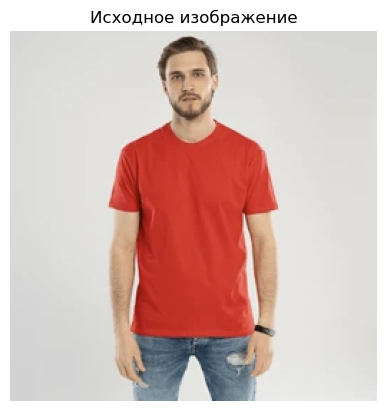

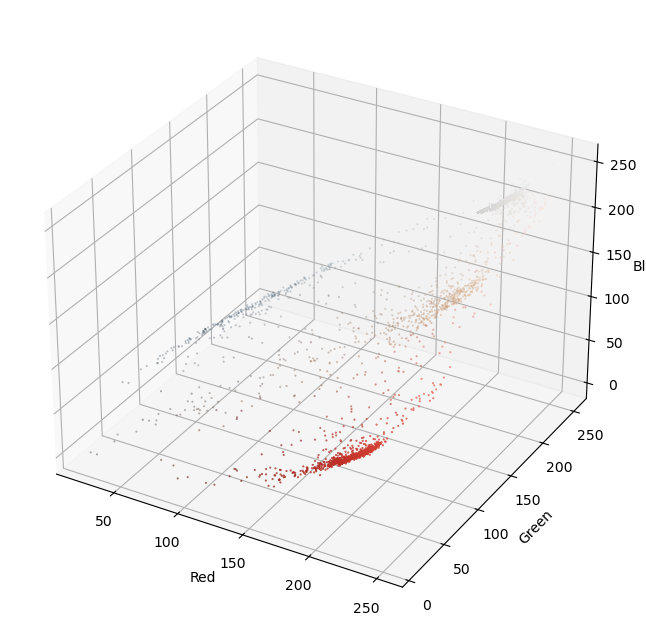

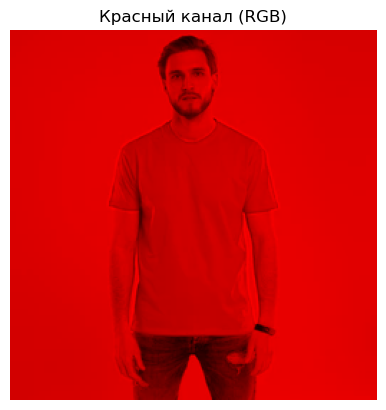

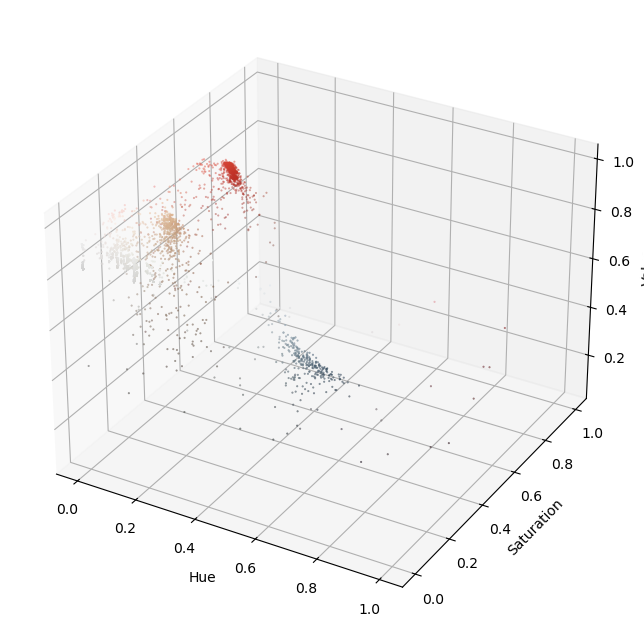

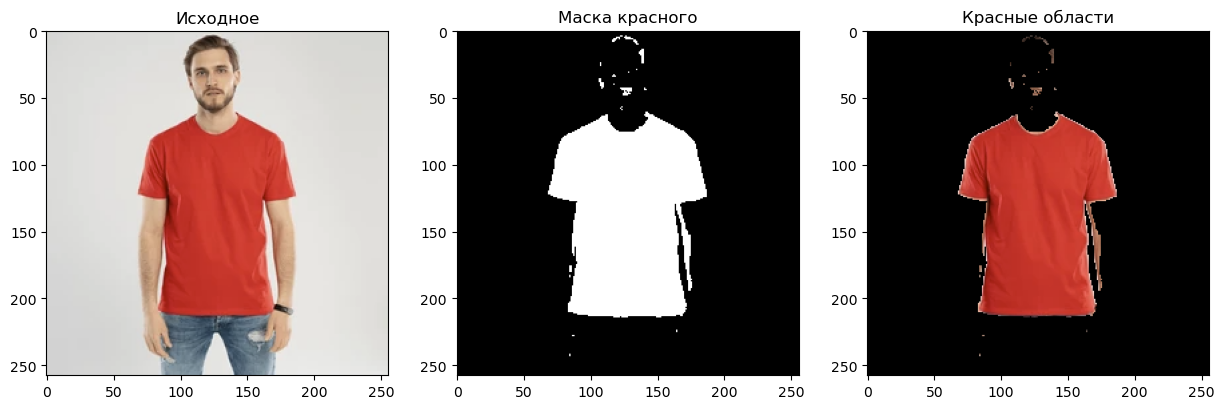

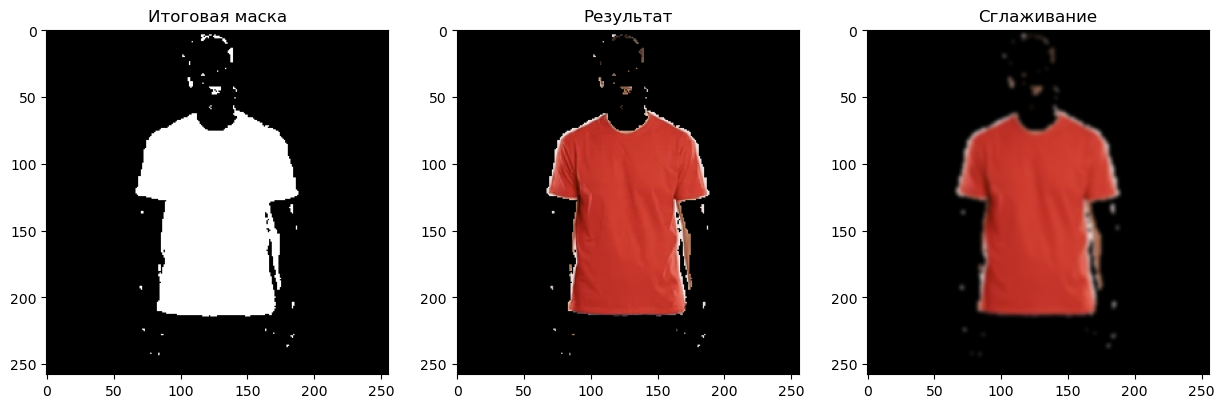

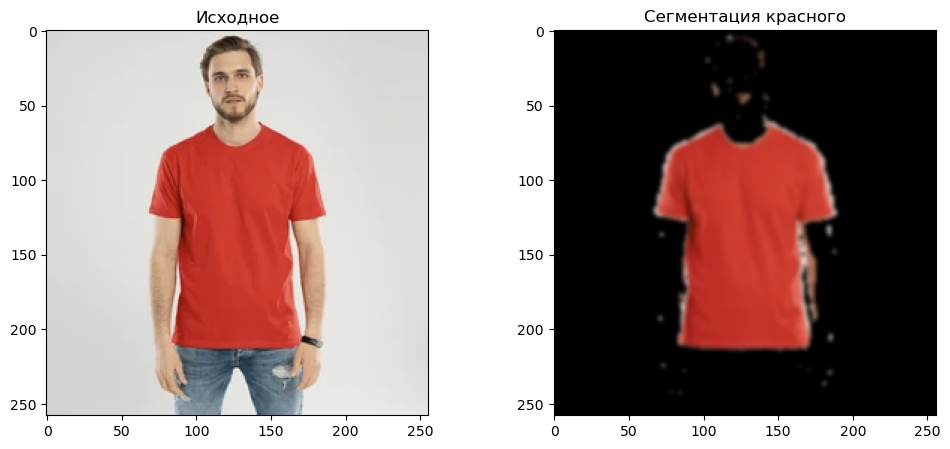

In [4]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
from matplotlib import colors
from matplotlib.colors import hsv_to_rgb


# Загрузка изображения (используем то же, но для красного)
image = cv.imread('./123.png')  # Замените на red.jpg при необходимости
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()


# Сэмплинг

r, g, b = cv.split(image_rgb)

step = 10
r_s = r.flatten()[::step]
g_s = g.flatten()[::step]
b_s = b.flatten()[::step]

pixel_colors = image_rgb.reshape((-1, 3))[::step]

norm = colors.Normalize(vmin=0, vmax=255)
pixel_colors = norm(pixel_colors).tolist()

fig = plt.figure(figsize=(8, 8))
axis = fig.add_subplot(111, projection="3d")

axis.scatter(r_s, g_s, b_s,
             facecolors=pixel_colors,
             marker=".",
             s=1)

axis.set_xlabel("Red")
axis.set_ylabel("Green")
axis.set_zlabel("Blue")
plt.show()


# Канал Red 
red = image_rgb.copy()
red[:, :, 1] = 0  # Green
red[:, :, 2] = 0  # Blue

plt.imshow(red)
plt.title("Красный канал (RGB)")
plt.axis("off")
plt.show()


# RGB в HSV
image_hsv = cv.cvtColor(image_rgb, cv.COLOR_RGB2HSV)
h, s, v = cv.split(image_hsv)

step = 10
h_s = h.flatten()[::step]
s_s = s.flatten()[::step]
v_s = v.flatten()[::step]

h_s = h_s / 179.0
s_s = s_s / 255.0
v_s = v_s / 255.0

# Цвета точек — реальные RGB
pixel_colors = image_rgb.reshape((-1, 3))[::step] / 255.0

fig = plt.figure(figsize=(8, 8))
axis = fig.add_subplot(111, projection="3d")

axis.scatter(h_s, s_s, v_s,
             facecolors=pixel_colors,
             marker=".",
             s=1)

axis.set_xlabel("Hue")
axis.set_ylabel("Saturation")
axis.set_zlabel("Value")

plt.show()

# Маска КРАСНОГО (HSV)
# Красный находится в двух диапазонах Hue: 0-10 и 170-179
lower_red1 = np.array([0, 40, 40])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 40, 40])
upper_red2 = np.array([179, 255, 255])

# Визуализация границ масок
lr1_square = np.full((10, 10, 3), lower_red1, dtype=np.uint8) / 255.0
ur1_square = np.full((10, 10, 3), upper_red1, dtype=np.uint8) / 255.0
lr2_square = np.full((10, 10, 3), lower_red2, dtype=np.uint8) / 255.0
ur2_square = np.full((10, 10, 3), upper_red2, dtype=np.uint8) / 255.0

# Применение маски (объединение двух диапазонов)
mask_red1 = cv.inRange(image_hsv, lower_red1, upper_red1)
mask_red2 = cv.inRange(image_hsv, lower_red2, upper_red2)
mask_red = cv.bitwise_or(mask_red1, mask_red2)

result_red = cv.bitwise_and(image_rgb, image_rgb, mask=mask_red)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Исходное")
plt.subplot(1, 3, 2)
plt.imshow(mask_red, cmap="gray")
plt.title("Маска красного")
plt.subplot(1, 3, 3)
plt.imshow(result_red)
plt.title("Красные области")
plt.show()

# Дополнительная маска для насыщенных красных оттенков
light_red1 = (0, 10, 180)
dark_red1 = (10, 120, 255)

light_red2 = (170, 10, 180)
dark_red2 = (179, 120, 255)

mask_light1 = cv.inRange(image_hsv, light_red1, dark_red1)
mask_light2 = cv.inRange(image_hsv, light_red2, dark_red2)
mask_light = cv.bitwise_or(mask_light1, mask_light2)

final_mask = cv.bitwise_or(mask_red, mask_light)
final_result = cv.bitwise_and(image_rgb, image_rgb, mask=final_mask)

blur = cv.GaussianBlur(final_result, (7, 7), 0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(final_mask, cmap="gray")
plt.title("Итоговая маска")
plt.subplot(1, 3, 2)
plt.imshow(final_result)
plt.title("Результат")
plt.subplot(1, 3, 3)
plt.imshow(blur)
plt.title("Сглаживание")
plt.show()

# Функция сегментации красного цвета
def segment_red(image):
    hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV)
    
    # Первый диапазон красного (0-10)
    lower_red1 = (0, 40, 40)
    upper_red1 = (10, 255, 255)
    
    # Второй диапазон красного (170-179)
    lower_red2 = (170, 40, 40)
    upper_red2 = (179, 255, 255)
    
    mask_red1 = cv.inRange(hsv, lower_red1, upper_red1)
    mask_red2 = cv.inRange(hsv, lower_red2, upper_red2)
    mask_red = cv.bitwise_or(mask_red1, mask_red2)
    
    # Дополнительные маски для насыщенных оттенков
    light_red1 = (0, 10, 180)
    dark_red1 = (10, 120, 255)
    
    light_red2 = (170, 10, 180)
    dark_red2 = (179, 120, 255)
    
    mask_light1 = cv.inRange(hsv, light_red1, dark_red1)
    mask_light2 = cv.inRange(hsv, light_red2, dark_red2)
    mask_light = cv.bitwise_or(mask_light1, mask_light2)
    
    final_mask = cv.bitwise_or(mask_red, mask_light)
    result = cv.bitwise_and(image, image, mask=final_mask)
    
    blur = cv.GaussianBlur(result, (7, 7), 0)
    return blur

segmented = segment_red(image_rgb)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Исходное")
plt.subplot(1, 2, 2)
plt.imshow(segmented)
plt.title("Сегментация красного")
plt.show()